# Penugasan Pengolahan Citra
## JOBSHEET 04: SEGMENTASI GAMBAR

**Nama:** Intan Nurul Faizia
**NIM:** 3.34.23.2.11


**Dosen Pengampu:** Ir. Prayitno, S.ST., M.T., Ph.D.  
**Program Studi:** STR Teknologi Rekayasa Komputer  
**Politeknik Negeri Semarang**

---
## Penugasan F No. 3 — Eksperimen Thresholding pada data.page()

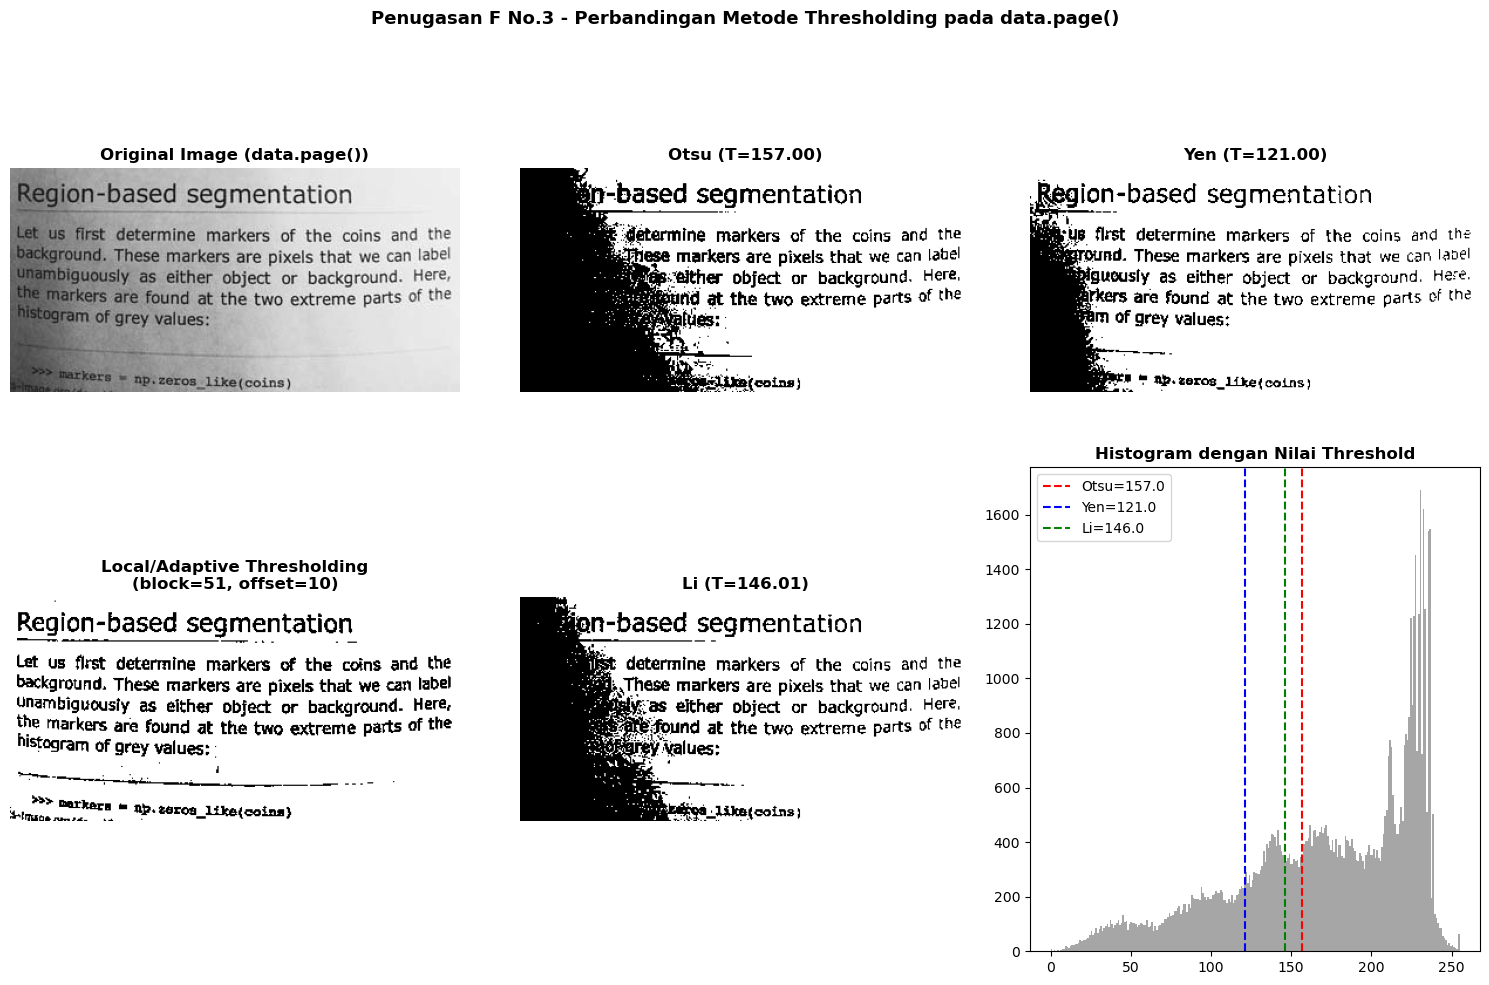

=== Nilai Threshold Masing-masing Metode ===
Otsu  : 157.00
Yen   : 121.00
Li    : 146.01
Local : adaptif per area (block_size=51)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Load citra data.page()
image_page = data.page()

# 2. Otsu Thresholding
thresh_otsu  = filters.threshold_otsu(image_page)
binary_otsu  = image_page > thresh_otsu

# 3. Yen Thresholding
thresh_yen   = filters.threshold_yen(image_page)
binary_yen   = image_page > thresh_yen

# 4. Local (Adaptive) Thresholding
thresh_local = filters.threshold_local(image_page, block_size=51, offset=10)
binary_local = image_page > thresh_local

# 5. Li Thresholding
thresh_li    = filters.threshold_li(image_page)
binary_li    = image_page > thresh_li

# 6. Visualisasi
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
ax = axes.ravel()

ax[0].imshow(image_page, cmap='gray')
ax[0].set_title('Original Image (data.page())', fontweight='bold')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu (T={thresh_otsu:.2f})', fontweight='bold')
ax[1].axis('off')

ax[2].imshow(binary_yen, cmap='gray')
ax[2].set_title(f'Yen (T={thresh_yen:.2f})', fontweight='bold')
ax[2].axis('off')

ax[3].imshow(binary_local, cmap='gray')
ax[3].set_title('Local/Adaptive Thresholding\n(block=51, offset=10)', fontweight='bold')
ax[3].axis('off')

ax[4].imshow(binary_li, cmap='gray')
ax[4].set_title(f'Li (T={thresh_li:.2f})', fontweight='bold')
ax[4].axis('off')

# Histogram dengan semua threshold
ax[5].hist(image_page.ravel(), bins=256, color='gray', alpha=0.7)
ax[5].axvline(thresh_otsu,  color='red',    linestyle='--', label=f'Otsu={thresh_otsu:.1f}')
ax[5].axvline(thresh_yen,   color='blue',   linestyle='--', label=f'Yen={thresh_yen:.1f}')
ax[5].axvline(thresh_li,    color='green',  linestyle='--', label=f'Li={thresh_li:.1f}')
ax[5].set_title('Histogram dengan Nilai Threshold', fontweight='bold')
ax[5].legend()

plt.suptitle('Penugasan F No.3 - Perbandingan Metode Thresholding pada data.page()',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("=== Nilai Threshold Masing-masing Metode ===")
print(f"Otsu  : {thresh_otsu:.2f}")
print(f"Yen   : {thresh_yen:.2f}")
print(f"Li    : {thresh_li:.2f}")
print(f"Local : adaptif per area (block_size=51)")

---
## Penugasan F No. 4 — Segmentasi pada Citra dari Internet (Buah-buahan)

Citra yang digunakan : data.coffee()
Ukuran citra         : (400, 600, 3)


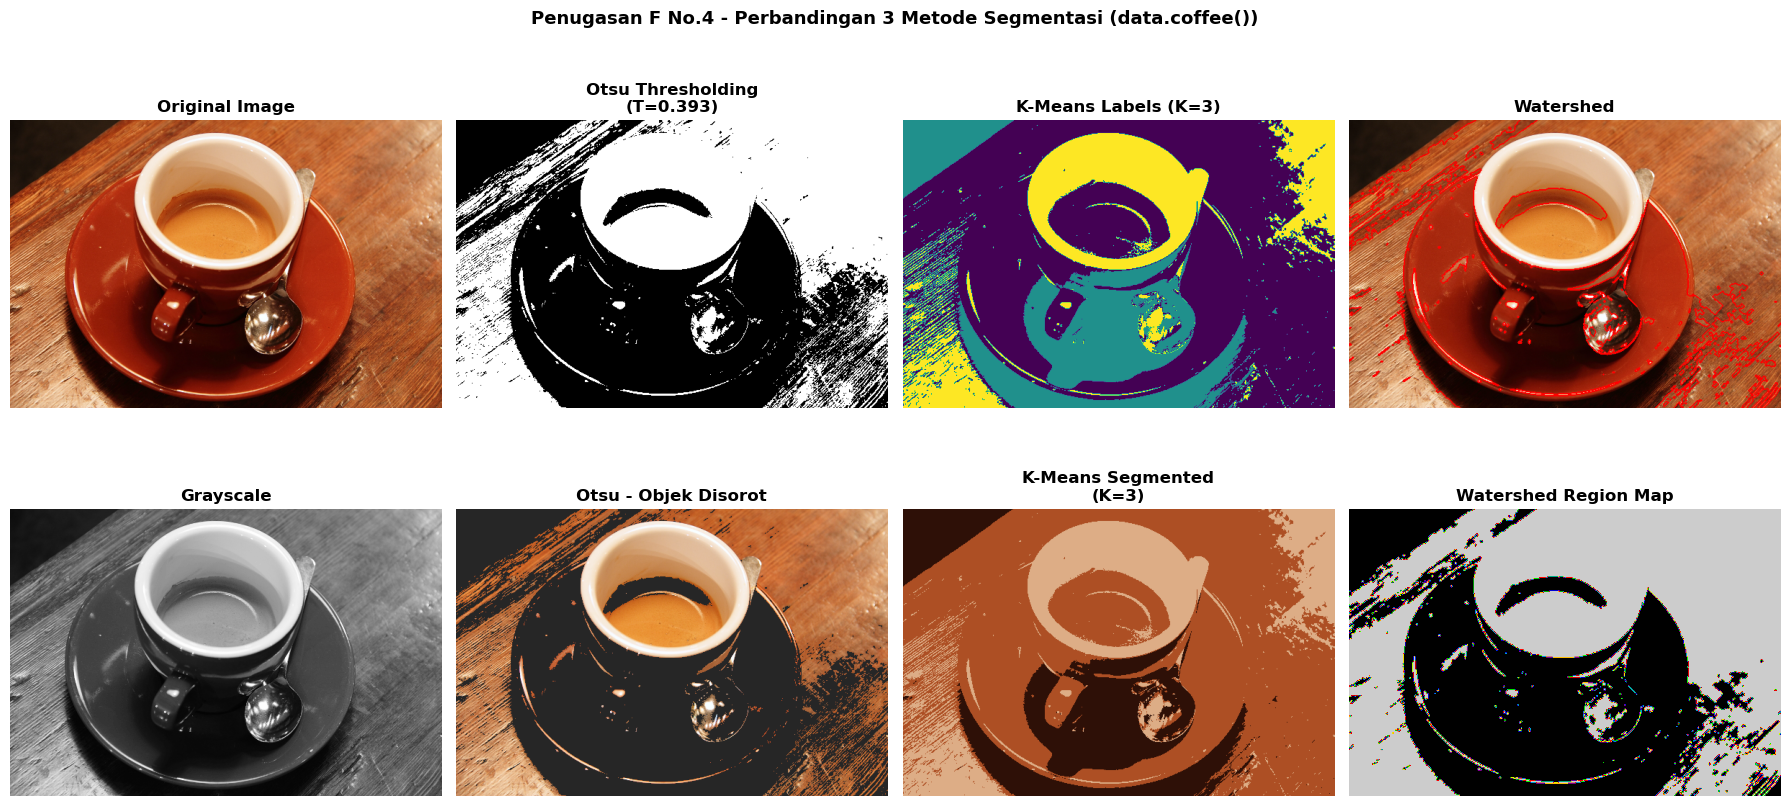

=== Ringkasan Hasil Segmentasi ===
Otsu threshold   : 0.3927
K-Means K        : 3 klaster
Watershed region : 2 region


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from skimage import data, filters, segmentation, img_as_float
from skimage.color import rgb2gray, rgb2lab, lab2rgb
from sklearn.cluster import KMeans

# ===================== LOAD CITRA (pakai bawaan skimage) =====================
# Menggunakan data.coffee() - citra cangkir kopi berwarna dengan latar belakang
# Bisa diganti dengan data.astronaut(), data.cat(), dll
image_color = data.coffee()          # citra RGB bawaan skimage
image_float = img_as_float(image_color)
image_gray  = rgb2gray(image_color)

print(f"Citra yang digunakan : data.coffee()")
print(f"Ukuran citra         : {image_color.shape}")

# ===================== METODE 1: OTSU THRESHOLDING =====================
thresh_otsu = filters.threshold_otsu(image_gray)
binary_otsu = image_gray > thresh_otsu

# ===================== METODE 2: K-MEANS (K=3) =====================
image_lab        = rgb2lab(image_float)
rows, cols, dims = image_lab.shape
pixel_features   = image_lab.reshape(rows * cols, dims)

n_clusters = 3
kmeans     = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_labels = pixel_labels.reshape(rows, cols)
segmented_kmeans = np.zeros_like(image_lab)
for k in range(n_clusters):
    mask_k = segmented_labels == k
    segmented_kmeans[mask_k] = kmeans.cluster_centers_[k]
segmented_kmeans_rgb = lab2rgb(segmented_kmeans)

# ===================== METODE 3: WATERSHED =====================
elevation_map = filters.sobel(image_gray)
markers = np.zeros(image_gray.shape, dtype=np.int32)
markers[image_gray < thresh_otsu * 0.7] = 1   # latar belakang
markers[image_gray > thresh_otsu * 1.1] = 2   # objek utama
segmentation_ws      = segmentation.watershed(elevation_map, markers)
segmented_ws_colored = segmentation.mark_boundaries(
    image_float, segmentation_ws, color=(1, 0, 0)
)

# ===================== VISUALISASI =====================
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
ax = axes.ravel()

# --- Baris 1 ---
ax[0].imshow(image_color)
ax[0].set_title('Original Image', fontweight='bold')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title(f'Otsu Thresholding\n(T={thresh_otsu:.3f})', fontweight='bold')
ax[1].axis('off')

ax[2].imshow(segmented_labels, cmap='viridis')
ax[2].set_title(f'K-Means Labels (K={n_clusters})', fontweight='bold')
ax[2].axis('off')

ax[3].imshow(segmented_ws_colored)
ax[3].set_title('Watershed', fontweight='bold')
ax[3].axis('off')

# --- Baris 2 ---
ax[4].imshow(image_gray, cmap='gray')
ax[4].set_title('Grayscale', fontweight='bold')
ax[4].axis('off')

# Otsu overlay pada citra warna
otsu_overlay = image_float.copy()
otsu_overlay[~binary_otsu] = [0.15, 0.15, 0.15]
ax[5].imshow(otsu_overlay)
ax[5].set_title('Otsu - Objek Disorot', fontweight='bold')
ax[5].axis('off')

ax[6].imshow(segmented_kmeans_rgb)
ax[6].set_title(f'K-Means Segmented\n(K={n_clusters})', fontweight='bold')
ax[6].axis('off')

ax[7].imshow(segmentation_ws, cmap='nipy_spectral')
ax[7].set_title('Watershed Region Map', fontweight='bold')
ax[7].axis('off')

plt.suptitle('Penugasan F No.4 - Perbandingan 3 Metode Segmentasi (data.coffee())',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ===================== RINGKASAN =====================
print("=== Ringkasan Hasil Segmentasi ===")
print(f"Otsu threshold   : {thresh_otsu:.4f}")
print(f"K-Means K        : {n_clusters} klaster")
print(f"Watershed region : {segmentation_ws.max()} region")